In [1]:
import torch
print(torch.cuda.is_available())   # should be True
print(torch.version.cuda)          # CUDA version PyTorch is built with
print(torch.cuda.get_device_name(0)) if torch.cuda.is_available() else None
print(torch.cuda.device_count())
import os
os.cpu_count()

True
11.7
NVIDIA RTX 6000 Ada Generation
2


48

In [2]:
import scanpy as sc

# Load your dataset
adata_4i = sc.read_h5ad("4i/8h.h5ad")

# Basic overview
print(adata_4i)
print("Shape:", adata_4i.shape)

# View column names (metadata about each cell)
print("Observation columns:", adata_4i.obs.columns.tolist()[:10])
print("Feature columns:", adata_4i.var_names[:10].tolist())

# How many drugs (conditions)?
print("Unique conditions:", adata_4i.obs['drug'].unique())
print("Number of cells per condition:")
print(adata_4i.obs['drug'].value_counts())



AnnData object with n_obs × n_vars = 119479 × 78
    obs: 'drug'
    var: 'cell_part', 'measurement', 'stat', 'feature', 'original'
    uns: 'source'
Shape: (119479, 78)
Observation columns: ['drug']
Feature columns: ['morphology-nuclei-area', 'morphology-nuclei-circularity', 'morphology-nuclei-convexity', 'morphology-nuclei-eccentricity', 'morphology-nuclei-elongation', 'morphology-nuclei-equivalent_diameter', 'morphology-nuclei-extent', 'morphology-nuclei-major_axis_length', 'morphology-nuclei-mean_radius', 'morphology-nuclei-perimeter']
Unique conditions: ['ixazomib', 'everolimus', 'olaparib', 'paclitaxel', 'vemurafenib_cobimetinib', ..., 'ixazomib_lenalidomide_dexamethasone', 'melphalan', 'ulixertinib', 'dasatinib', 'sec.abcl']
Length: 38
Categories (38, object): ['cisplatin', 'cisplatin_olaparib', 'cl', 'control', ..., 'trametinib_panobinostat', 'ulixertinib', 'vemurafenib_cobimetinib', 'vindesine']
Number of cells per condition:
cl                                        18332
con

In [3]:
features_4i = [
    "intensity-cell-CD45-mean",
    "intensity-cell-ClCasp3-mean",
    "intensity-cell-DAPI-sum",
    "intensity-cell-Ki67-mean",
    "intensity-cell-MelA-mean",
    "intensity-cell-PCNA-mean",
    "intensity-cell-Sox9-mean",
    "intensity-cell-aTUB-mean",
    "intensity-cell-pAKT-mean",
    "intensity-cell-pEGFR-mean",
    "intensity-cell-pERK-mean",
    "intensity-cell-pMET-mean",
    "intensity-cell-pS6k1-mean",
    "intensity-nuclei-CD45-mean",
    "intensity-nuclei-ClCasp3-mean",
    "intensity-nuclei-DAPI-sum",
    "intensity-nuclei-Ki67-mean",
    "intensity-nuclei-MelA-mean",
    "intensity-nuclei-PCNA-mean",
    "intensity-nuclei-Sox9-mean",
    "intensity-nuclei-aTUB-mean",
    "intensity-nuclei-pAKT-mean",
    "intensity-nuclei-pEGFR-mean",
    "intensity-nuclei-pERK-mean",
    "intensity-nuclei-pMET-mean",
    "intensity-nuclei-pS6k1-mean",
    "morphology-cell-area",
    "morphology-cell-circularity",
    "morphology-cell-convexity",
    "morphology-cell-eccentricity",
    "morphology-cell-elongation",
    "morphology-cell-equivalent_diameter",
    "morphology-cell-extent",
    "morphology-cell-major_axis_length",
    "morphology-cell-mean_radius",
    "morphology-cell-perimeter",
    "morphology-cell-roundness",
    "morphology-nuclei-area",
    "morphology-nuclei-circularity",
    "morphology-nuclei-convexity",
    "morphology-nuclei-eccentricity",
    "morphology-nuclei-elongation",
    "morphology-nuclei-equivalent_diameter",
    "morphology-nuclei-extent",
    "morphology-nuclei-major_axis_length",
    "morphology-nuclei-mean_radius",
    "morphology-nuclei-perimeter",
    "morphology-nuclei-roundness"
]


In [4]:
import os
import sys
import json
import logging
import argparse
import geomloss
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from tqdm import tqdm
import numpy as np
import pandas as pd
from pathlib import Path
from typing import Dict, Tuple, List, Optional
from umap import UMAP
import matplotlib.pyplot as plt
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics.pairwise import rbf_kernel
from typing import Dict, Tuple, List
from scipy.stats import ks_2samp
from scipy.spatial.distance import cdist
from sklearn.metrics import r2_score

import gc
gc.collect()

def median_heuristic_gamma(X: np.ndarray, Y: np.ndarray) -> float:
    """
    Median heuristic for RBF bandwidth: gamma = 1 / median(||x - y||^2).
    Uses the median of pairwise distances in the pooled set.
    """
    Z = np.vstack([X, Y])
    # Sample if too large for efficiency
    max_samples = 5000
    if Z.shape[0] > max_samples:
        idx = np.random.choice(Z.shape[0], size=max_samples, replace=False)
        Z = Z[idx]
    D2 = cdist(Z, Z, metric='sqeuclidean')
    # Use upper triangular without diagonal
    triu = D2[np.triu_indices_from(D2, k=1)]
    med = np.median(triu[triu > 0]) if np.any(triu > 0) else 1.0
    return 1.0 / max(med, 1e-12)

def mmd_distance(X: np.ndarray, Y: np.ndarray, gamma: float) -> float:
    """
    Unbiased MMD^2 estimator using Gaussian (RBF) kernel, sklearn backend.

    Args:
        X: (n_samples, n_features) first sample
        Y: (m_samples, n_features) second sample
        gamma: RBF kernel bandwidth; if None, uses median heuristic

    Returns:
        Unbiased MMD^2 value
    """
    n = X.shape[0]
    m = Y.shape[0]

    # Kernel matrices
    Kxx = rbf_kernel(X, X, gamma=gamma)
    Kyy = rbf_kernel(Y, Y, gamma=gamma)
    Kxy = rbf_kernel(X, Y, gamma=gamma)

    # Unbiased: exclude diagonal entries
    np.fill_diagonal(Kxx, 0.0)
    np.fill_diagonal(Kyy, 0.0)

    term_xx = Kxx.sum() / (n * (n - 1)) if n > 1 else 0.0
    term_yy = Kyy.sum() / (m * (m - 1)) if m > 1 else 0.0
    term_xy = 2.0 * Kxy.mean()

    mmd2 = term_xx + term_yy - term_xy
    mmd2 = max(mmd2, 0.0)  # Numerical stability
    return float(mmd2)

def r2_feature_means(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    """
    R^2 computed across features between mean vectors of y_true and y_pred.
    """
    mu_true = y_true.mean(axis=0)
    mu_pred = y_pred.mean(axis=0)
    ss_res = float(np.sum((mu_true - mu_pred) ** 2))
    ss_tot = float(np.sum((mu_true - mu_true.mean()) ** 2))
    if ss_tot <= 1e-12:
        return 1.0 if ss_res <= 1e-12 else 0.0
    return 1.0 - ss_res / ss_tot

def wasserstein_pointcloud(
    X,
    Y,
    p: int = 2,
    a=None,
    b=None,
    method: str = "emd",          # "emd" (exact) or "sinkhorn" (approx)
    reg: float = 1e-1,            # Sinkhorn regularization (only used if method="sinkhorn")
    return_plan: bool = False,
):
    """
    Compute Wasserstein distance W_p between two empirical distributions supported on point sets X and Y.

    Parameters
    ----------
    X : (n, d) array-like
        Source points.
    Y : (m, d) array-like
        Target points.
    p : int
        Order of the Wasserstein distance (commonly 1 or 2).
    a : (n,) array-like or None
        Weights for X; if None, uniform weights.
    b : (m,) array-like or None
        Weights for Y; if None, uniform weights.
    method : str
        "emd" for exact optimal transport (requires POT),
        "sinkhorn" for entropic approximation (requires POT).
    reg : float
        Entropic regularization strength for Sinkhorn.
    return_plan : bool
        If True, also return the optimal transport plan.

    Returns
    -------
    Wp : float
        Wasserstein distance of order p.
    plan : (n, m) ndarray, optional
        Optimal transport plan (only if return_plan=True).
    """
    X = np.asarray(X, dtype=np.float64)
    Y = np.asarray(Y, dtype=np.float64)
    if X.ndim != 2 or Y.ndim != 2:
        raise ValueError("X and Y must be 2D arrays with shape (n, d) and (m, d).")
    if X.shape[1] != Y.shape[1]:
        raise ValueError(f"Dimension mismatch: X has d={X.shape[1]}, Y has d={Y.shape[1]}.")

    n, d = X.shape
    m, _ = Y.shape

    if a is None:
        a = np.full(n, 1.0 / n, dtype=np.float64)
    else:
        a = np.asarray(a, dtype=np.float64)
        a = a / a.sum()

    if b is None:
        b = np.full(m, 1.0 / m, dtype=np.float64)
    else:
        b = np.asarray(b, dtype=np.float64)
        b = b / b.sum()

    # Cost matrix: C_ij = ||x_i - y_j||^p
    # Compute squared Euclidean via (x-y)^2 = x^2 + y^2 - 2xy for speed
    X2 = np.sum(X * X, axis=1, keepdims=True)          # (n, 1)
    Y2 = np.sum(Y * Y, axis=1, keepdims=True).T        # (1, m)
    sq = np.maximum(X2 + Y2 - 2.0 * (X @ Y.T), 0.0)     # (n, m)
    if p == 2:
        C = sq
    else:
        C = sq ** (p / 2.0)

    try:
        import ot  # POT: Python Optimal Transport
    except ImportError as e:
        raise ImportError(
            "This function requires the POT library. Install with: pip install pot"
        ) from e

    method = method.lower()
    if method == "emd":
        # exact OT: minimizes <P, C>
        P = ot.emd(a, b, C)
        cost = float(np.sum(P * C))
    elif method == "sinkhorn":
        # entropic OT approximation
        P = ot.sinkhorn(a, b, C, reg=reg)
        cost = float(np.sum(P * C))
    else:
        raise ValueError('method must be either "emd" or "sinkhorn".')

    Wp = cost ** (1.0 / p)

    if return_plan:
        return Wp, P
    return Wp

def summarize_metrics(y_true: np.ndarray, y_pred: np.ndarray, median_gamma: float) -> dict:
    """
    Compute a standard set of metrics: MMD^2 (RBF), R^2 of feature means, median KS across features, and Wasserstein distance.
    """
    # Drop any samples that contain NaNs in either true or pred
    mask = (~np.isnan(y_true).any(axis=1)) & (~np.isnan(y_pred).any(axis=1))
    if mask.sum() < len(y_true):
        print(f"[summarize_metrics] Dropping {len(y_true) - mask.sum()} samples with NaNs.")
    
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    out = {}

    out['mmd2_gamma_median'] = mmd_distance(y_true, y_pred, gamma=median_gamma)
    out['mmd2_gamma_0.5'] = mmd_distance(y_true, y_pred, gamma=0.5)
    out['mmd2_gamma_1.0'] = mmd_distance(y_true, y_pred, gamma=1.0)
    out['wasserstein_distance'] = wasserstein_pointcloud(y_true, y_pred, p=2, method="emd")
    out['R2_feature_means'] = r2_feature_means(y_true, y_pred)
    return out

def split_train_test(X: np.ndarray, Y: np.ndarray, train_fraction: float, seed: int = 42) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    if X.shape[0] != Y.shape[0]:
        min_len = min(len(X), len(Y))
        X = X[:min_len]
        Y = Y[:min_len]

    n = X.shape[0]
    n_train = max(1, int(n * train_fraction))
    rng = np.random.default_rng(seed)
    idx = rng.permutation(n)
    tr_idx, te_idx = idx[:n_train], idx[n_train:]
    return X[tr_idx], X[te_idx], Y[tr_idx], Y[te_idx]

def topk_markers(adata, drug: str, k: int = 50, rank_key: str = "marker_genes-drug-rank"):
    R = adata.varm[rank_key]

    # --- get the rank vector for this drug ---
    if hasattr(R, "columns") and hasattr(R, "iloc"):  # pandas DataFrame
        if drug in R.columns:
            r = R[drug].to_numpy()
        else:
            # fallback: interpret columns as ordered groups; try to map via rank_genes_groups names
            names = adata.uns["rank_genes_groups"]["names"]
            groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
            r = R.iloc[:, groups.index(drug)].to_numpy()
    else:  # numpy array (or array-like)
        names = adata.uns["rank_genes_groups"]["names"]
        groups = list(names.dtype.names) if (hasattr(names, "dtype") and names.dtype.names is not None) else list(names.columns)
        r = np.asarray(R)[:, groups.index(drug)]

    # smaller rank => stronger marker
    idx = np.argsort(r)[:k]
    gene_ids = adata.var_names[idx].to_list()
    gene_short = (adata.var.iloc[idx]["gene_short_name"].to_list()
                  if "gene_short_name" in adata.var.columns else None)
    return gene_ids, gene_short, idx


In [5]:
import scgen

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/pytorch_lightning/utilities/imports.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Global seed set to 0
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/pytorch_lightning/utilities/warnings.py:53: LightningDeprecationWarning: pytorch_lightning.utilities.warnings.rank_zero_deprecation has been deprecated in v1.6 and will be removed in v1.8. Use the equivalent function from the pytorch_lightning.utilities.rank_zero module instead.
  new_rank_zero_deprecation(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/pytorch_lightning/utilities/warnings.py:58: LightningDeprecationWarning: The `pytorch_lightning.loggers.base.rank_zero_experiment` is deprecated in v1.7 an

In [6]:
def SCGEN(
    X_tr_pre, Y_tr_post, X_te_pre, Y_te_post,
    max_epochs=1000,
    batch_size=64,
    early_stopping=True,
    early_stopping_patience=50,
    condition_key="condition",
    ctrl_label="control",
    stim_label="treated",
    cell_type_key="cell_type",
    cell_type_label="cell",
    n_hidden=256,
    n_latent=50,
    n_layers=2,
    dropout_rate=0.2,
    accelerator="auto",   # "auto" | "cpu" | "gpu" | "mps"
    learning_rate=5e-4,
    seed=12345,
    verbose=True,
    metrics_fn=None,      # e.g., summarize_metrics(y_true, y_pred)
):
    import numpy as np
    import pandas as pd
    import random

    try:
        import anndata as ad
        import torch
        import scgen
        try:
            import scvi
        except Exception:
            scvi = None
    except Exception as e:
        msg = str(e)
        hint = None
        if "scvi._compat" in msg:
            hint = (
                "Likely scGen (PyPI) vs scvi-tools mismatch. "
                "Try: pip uninstall -y scgen && pip install git+https://github.com/theislab/scgen.git"
            )
        return {"error": f"Import failed: {e}", "hint": hint}

    # ----------- Validate shapes -----------
    X_tr_pre = np.asarray(X_tr_pre); Y_tr_post = np.asarray(Y_tr_post)
    X_te_pre = np.asarray(X_te_pre); Y_te_post = np.asarray(Y_te_post)

    if any(a.ndim != 2 for a in [X_tr_pre, Y_tr_post, X_te_pre, Y_te_post]):
        return {"error": "All inputs must be 2D arrays (n_cells, n_features)."}
    d = X_tr_pre.shape[1]
    if any(a.shape[1] != d for a in [Y_tr_post, X_te_pre, Y_te_post]):
        return {"error": "Feature dimension mismatch across inputs."}

    # ----------- Seeds -----------
    random.seed(seed); np.random.seed(seed)
    try:
        torch.manual_seed(seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(seed)
    except Exception:
        pass
    if scvi is not None:
        try:
            scvi.settings.seed = seed
        except Exception:
            pass

    # ----------- Accelerator selection -----------
    def _auto_accel():
        if torch.cuda.is_available():
            return "gpu"
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return "mps"
        return "cpu"
    accelerator_used = _auto_accel() if accelerator == "auto" else accelerator

    # ----------- Build training AnnData -----------
    try:
        X_tr_all = np.vstack([X_tr_pre, Y_tr_post]).astype(np.float32, copy=False)
        cond_tr = np.array([ctrl_label] * len(X_tr_pre) + [stim_label] * len(Y_tr_post), dtype=object)
        ctype_tr = np.array([cell_type_label] * len(X_tr_all), dtype=object)

        ad_tr = ad.AnnData(
            X_tr_all,
            obs=pd.DataFrame({condition_key: cond_tr, cell_type_key: ctype_tr})
        )
        # avoid "Observation names are not unique"
        ad_tr.obs_names = [f"tr_{i}" for i in range(ad_tr.n_obs)]
        ad_tr.var_names = [f"g_{j}" for j in range(ad_tr.n_vars)]

        scgen.SCGEN.setup_anndata(ad_tr, batch_key=condition_key, labels_key=cell_type_key)

        model = scgen.SCGEN(
            ad_tr,
            n_hidden=n_hidden,
            n_latent=n_latent,
            n_layers=n_layers,
            dropout_rate=dropout_rate,
        )

        train_kwargs = dict(
            max_epochs=int(max_epochs),
            batch_size=int(batch_size),
            early_stopping=bool(early_stopping),
            early_stopping_patience=int(early_stopping_patience),
            enable_progress_bar=bool(verbose),
            plan_kwargs={"lr": float(learning_rate)},
        )


        model.train(**train_kwargs)

    except Exception as e:
        return {"error": f"scGen training failed: {e}"}

    # ----------- Predict treated for test controls -----------
    try:
        ad_te = ad.AnnData(
            X_te_pre.astype(np.float32, copy=False),
            obs=pd.DataFrame({
                condition_key: np.array([ctrl_label] * len(X_te_pre), dtype=object),
                cell_type_key: np.array([cell_type_label] * len(X_te_pre), dtype=object),
            })
        )
        ad_te.obs_names = [f"te_{i}" for i in range(ad_te.n_obs)]
        ad_te.var_names = ad_tr.var_names.copy()  # ensure exact match

        # IMPORTANT: pass ONLY adata_to_predict OR celltype_to_predict (not both). :contentReference[oaicite:3]{index=3}
        pred_adata, delta = model.predict(
            ctrl_key=ctrl_label,
            stim_key=stim_label,
            adata_to_predict=ad_te,
        )

        y_pred = np.asarray(pred_adata.X)

        if metrics_fn is None:
            metrics_fn = globals().get("summarize_metrics", None)

        metrics = None
        if callable(metrics_fn):
            n = min(len(Y_te_post), y_pred.shape[0])
            metrics = metrics_fn(Y_te_post[:n], y_pred[:n], median_gamma)

        return {
            "y_pred": y_pred,
            "metrics": metrics,
            "delta": delta,
            "model": model,
            "adata_train": ad_tr,
            "accelerator_used": accelerator_used,
        }

    except Exception as e:
        return {"error": f"scGen prediction failed: {e}"}


X_pre cells: (10995, 48)
X_post cells: (2637, 48)
(2109, 48)
(528, 48)
(2109, 48)
(528, 48)


Global seed set to 1234


Median heuristic gamma: 0.08064887236416649
**************** Run: 0 ****************


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 53/1000:   5%|███████████                                                                                                                                                                                                      | 53/1000 [00:14<04:22,  3.61it/s, loss=0.829, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 24.889. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 53/1000:   5%|███████████                                                                                                                                                                                                      | 53/1000 [00:13<04:02,  3.91it/s, loss=0.815, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 25.332. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Run 9 metrics: {'mmd2_gamma_median': 0.008970611724585797, 'mmd2_gamma_0.5': 0.016257080594608564, 'mmd2_gamma_1.0': 0.010044285116606572, 'wasserstein_distance': 1.6790582820493778, 'R2_feature_means': 0.9337603136474205}
                        mean     std
mmd2_gamma_median     0.0098  0.0020
mmd2_gamma_0.5        0.0184  0.0024
mmd2_gamma_1.0        0.0121  0.0016
wasserstein_distance  1.6839  0.0261
R2_feature_means      0.9302  0.0275


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

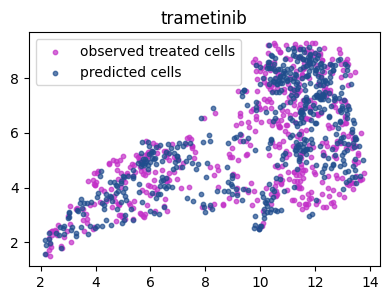

In [7]:
drug = "trametinib"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = SCGEN(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, max_epochs=1000, batch_size=64, seed=seed)
    metrics = summarize_metrics(out["y_pred"], Y_te_post, median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))



from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C331C8")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/scgen_on_4i_drug_{drug}.png", dpi=300)

X_pre cells: (10995, 48)
X_post cells: (2631, 48)
(2104, 48)
(527, 48)
(2104, 48)
(527, 48)


Global seed set to 1234


Median heuristic gamma: 0.05748945574198288
**************** Run: 0 ****************


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 53/1000:   5%|███████████                                                                                                                                                                                                      | 53/1000 [00:16<04:55,  3.20it/s, loss=0.932, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 25.870. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 53/1000:   5%|███████████▏                                                                                                                                                                                                      | 53/1000 [00:16<04:52,  3.24it/s, loss=1.04, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 28.167. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Run 9 metrics: {'mmd2_gamma_median': 0.025947770164266637, 'mmd2_gamma_0.5': 0.021814096921886433, 'mmd2_gamma_1.0': 0.009221653816619154, 'wasserstein_distance': 1.993892932046264, 'R2_feature_means': 0.9657142061284272}
                        mean     std
mmd2_gamma_median     0.0330  0.0034
mmd2_gamma_0.5        0.0257  0.0029
mmd2_gamma_1.0        0.0107  0.0010
wasserstein_distance  2.0667  0.0521
R2_feature_means      0.9149  0.0502


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

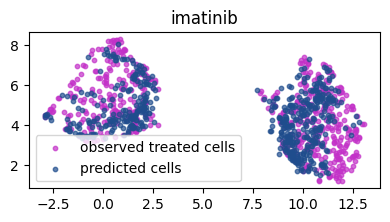

In [8]:
drug = "imatinib"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = SCGEN(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, max_epochs=1000, batch_size=64, seed=seed)
    metrics = summarize_metrics(out["y_pred"], Y_te_post, median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))



from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C331C8")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/scgen_on_4i_drug_{drug}.png", dpi=300)

X_pre cells: (10995, 48)
X_post cells: (2693, 48)
(2154, 48)
(539, 48)
(2154, 48)
(539, 48)


Global seed set to 1234


Median heuristic gamma: 0.07603466947967093
**************** Run: 0 ****************


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 53/1000:   5%|███████████                                                                                                                                                                                                      | 53/1000 [00:15<04:37,  3.41it/s, loss=0.782, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 26.773. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 53/1000:   5%|███████████                                                                                                                                                                                                      | 53/1000 [00:15<04:35,  3.43it/s, loss=0.805, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 25.876. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Run 9 metrics: {'mmd2_gamma_median': 0.011891730208393403, 'mmd2_gamma_0.5': 0.01355791787439807, 'mmd2_gamma_1.0': 0.007771959604269116, 'wasserstein_distance': 1.7776509756800218, 'R2_feature_means': 0.46591316936741944}
                        mean     std
mmd2_gamma_median     0.0096  0.0017
mmd2_gamma_0.5        0.0117  0.0014
mmd2_gamma_1.0        0.0068  0.0007
wasserstein_distance  1.7649  0.0165
R2_feature_means      0.6547  0.0921


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

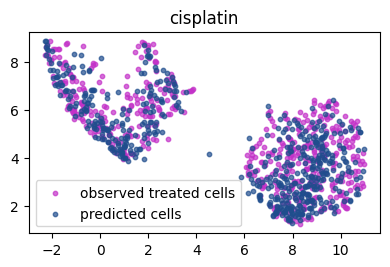

In [9]:
drug = "cisplatin"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = SCGEN(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, max_epochs=1000, batch_size=64, seed=seed)
    metrics = summarize_metrics(out["y_pred"], Y_te_post, median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))



from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C331C8")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/scgen_on_4i_drug_{drug}.png", dpi=300)

X_pre cells: (10995, 48)
X_post cells: (2796, 48)
(2236, 48)
(560, 48)
(2236, 48)
(560, 48)


Global seed set to 1234


Median heuristic gamma: 0.074449069228528
**************** Run: 0 ****************


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 53/1000:   5%|███████████                                                                                                                                                                                                      | 53/1000 [00:15<04:31,  3.49it/s, loss=0.903, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 24.981. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


...

/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]


Epoch 53/1000:   5%|███████████                                                                                                                                                                                                      | 53/1000 [00:15<04:45,  3.32it/s, loss=0.862, v_num=1]
Monitored metric elbo_validation did not improve in the last 50 records. Best score: 25.411. Signaling Trainer to stop.
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Received view of anndata, making copy.                                                                    
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             
INFO     Input AnnData not setup with scvi-tools. attempting to transfer AnnData setup                             


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/anndata/_core/anndata.py:1828: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


Run 9 metrics: {'mmd2_gamma_median': 0.015915531607872846, 'mmd2_gamma_0.5': 0.021241188055728583, 'mmd2_gamma_1.0': 0.010994170164007302, 'wasserstein_distance': 1.9842334362426135, 'R2_feature_means': 0.7891695121729075}
                        mean     std
mmd2_gamma_median     0.0160  0.0022
mmd2_gamma_0.5        0.0215  0.0016
mmd2_gamma_1.0        0.0113  0.0008
wasserstein_distance  1.9861  0.0197
R2_feature_means      0.7500  0.0721


/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/u/jrp5td/here/miniconda3/envs/scgen-env/lib/python3.9/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_fini

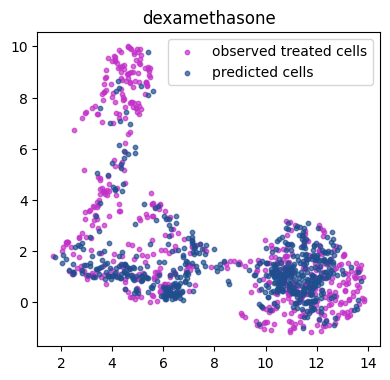

In [10]:
drug = "dexamethasone"
X_pre = adata_4i[adata_4i.obs["drug"] == "control"].copy().to_df()[features_4i]
X_post  = adata_4i[adata_4i.obs["drug"] == drug].copy().to_df()[features_4i]

print("X_pre cells:", X_pre.shape)
print("X_post cells:", X_post.shape)

X_tr_pre, X_te_pre, Y_tr_post, Y_te_post = split_train_test(X_pre.values, X_post.values, 0.8)

print(X_tr_pre.shape)
print(X_te_pre.shape)
print(Y_tr_post.shape)
print(Y_te_post.shape)

# Compute median heuristic gamma on training data
median_gamma = median_heuristic_gamma(X_tr_pre, Y_tr_post)
print("Median heuristic gamma:", median_gamma)


all_metrics = []
for run in range(10):
    print(f"**************** Run: {run} ****************")
    seed = 1234 + run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    out = SCGEN(X_tr_pre, Y_tr_post, X_te_pre, Y_te_post, max_epochs=1000, batch_size=64, seed=seed)
    metrics = summarize_metrics(out["y_pred"], Y_te_post, median_gamma)
    print(f"Run {run} metrics: {metrics}")
    all_metrics.append(metrics)

# Results summary
df = pd.DataFrame(all_metrics)
print(df.describe().T[['mean', 'std']].round(4))



from umap import UMAP
import matplotlib.pyplot as plt

source = Y_tr_post
target = Y_te_post
predicted = out.get('y_pred') 

# Instantiate UMAP
umap_model = UMAP(n_components=2, random_state=42)

all_sample_umap = umap_model.fit_transform(np.vstack([source, target]))
source_umap = umap_model.transform(source)
target_umap = umap_model.transform(target)
y_pred_umap = umap_model.transform(predicted)

fig, ax = plt.subplots(figsize=(4, 4))
# ax.scatter(source_umap[:, 0], source_umap[:, 1], s=10, alpha=0.7, label='train_post', color='C2')
ax.scatter(target_umap[:, 0], target_umap[:, 1], s=10, alpha=0.7, label='observed treated cells', color="#C331C8")
ax.scatter(y_pred_umap[:, 0], y_pred_umap[:, 1], s=10, alpha=0.7, label='predicted cells', color="#1F4D8D")

ax.set_title(f'{drug}')
# ax.set_xlabel('UMAP 1')
# ax.set_ylabel('UMAP 2')
ax.set_aspect('equal', 'box')
# Add a legend to distinguish the points
ax.legend()
# Adjust layout
plt.tight_layout()
# Display the plot
plt.savefig(f"./plots/scgen_on_4i_drug_{drug}.png", dpi=300)